In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import io

# Konfigurasi Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def load_network_data(file_path):
    with open(file_path, 'r') as f:
        lines = f.readlines()
    cleaned = [line.strip().replace('"', '') for line in lines]
    df = pd.read_csv(io.StringIO("\n".join(cleaned)), sep=';', decimal=',')
    return df

df_asli = load_network_data('dataset_dqn_rich.csv')
features_cols = [c for c in df_asli.columns if c != 'timestamp']
df_features = df_asli[features_cols]

print(f"Dataset Asli: {len(df_asli)} baris dimuat.")

Dataset Asli: 1022 baris dimuat.


In [2]:
# Gunakan StandardScaler agar PCA lebih bulat dan tidak rata (flat)
scaler = StandardScaler()
feat_scaled = scaler.fit_transform(df_features)

def create_training_seed(X, n_target=5000):
    n_current = X.shape[0]
    # 70% Data Asli (untuk Overlap)
    idx_real = np.random.choice(n_current, int(n_target*0.7))
    # 30% Variasi Pancingan (untuk Augmentasi)
    idx_var = np.random.choice(n_current, int(n_target*0.3))
    
    seed_data = X[idx_real]
    noisy_data = X[idx_var] + np.random.normal(0, 0.5, (len(idx_var), X.shape[1]))
    
    return np.vstack([seed_data, noisy_data])

X_train = create_training_seed(feat_scaled)
print(f"Data Pelatihan (Seed) Siap: {X_train.shape[0]} baris.")

Data Pelatihan (Seed) Siap: 5000 baris.


In [3]:
class Generator(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.main = nn.Sequential(
            nn.Linear(in_dim, 256), nn.ReLU(),
            nn.Linear(256, 512), nn.ReLU(),
            nn.Linear(512, out_dim) # Output linear agar sebaran tidak 'rata'
        )
    def forward(self, z): return self.main(z)

class Critic(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.main = nn.Sequential(
            nn.Linear(in_dim, 512), nn.LeakyReLU(0.2),
            nn.Linear(512, 256), nn.LeakyReLU(0.2),
            nn.Linear(256, 1)
        )
    def forward(self, x): return self.main(x)

def compute_gp(critic, real, fake):
    alpha = torch.rand(real.size(0), 1).to(device)
    interpolates = (alpha * real + (1 - alpha) * fake).requires_grad_(True)
    d_interpolates = critic(interpolates)
    gradients = torch.autograd.grad(outputs=d_interpolates, inputs=interpolates,
                                    grad_outputs=torch.ones_like(d_interpolates),
                                    create_graph=True, retain_graph=True)[0]
    return ((gradients.norm(2, dim=1) - 1) ** 2).mean()

latent_dim = 100
gen = Generator(latent_dim, len(features_cols)).to(device)
critic = Critic(len(features_cols)).to(device)
opt_gen = optim.Adam(gen.parameters(), lr=1e-4, betas=(0.5, 0.9))
opt_critic = optim.Adam(critic.parameters(), lr=1e-4, betas=(0.5, 0.9))

In [4]:
loader = torch.utils.data.DataLoader(torch.FloatTensor(X_train).to(device), batch_size=64, shuffle=True)

print("Training sedang berjalan...")
for epoch in range(301):
    for real in loader:
        noise = torch.randn(real.size(0), latent_dim).to(device)
        fake = gen(noise)
        # Update Critic
        loss_c = critic(fake).mean() - critic(real).mean() + 10 * compute_gp(critic, real, fake)
        opt_critic.zero_grad(); loss_c.backward(); opt_critic.step()
        # Update Generator
        if epoch % 5 == 0:
            loss_g = -critic(gen(noise)).mean()
            opt_gen.zero_grad(); loss_g.backward(); opt_gen.step()
    if epoch % 100 == 0:
        print(f"Epoch {epoch} | Loss G: {loss_g.item():.4f}")

Training sedang berjalan...
Epoch 0 | Loss G: -3.7992
Epoch 100 | Loss G: -1.0461
Epoch 200 | Loss G: 1.2085
Epoch 300 | Loss G: 2.0498


In [5]:
with torch.no_grad():
    noise = torch.randn(15000, latent_dim).to(device)
    synth_raw = gen(noise).cpu().numpy()

df_synth = pd.DataFrame(scaler.inverse_transform(synth_raw), columns=features_cols)

# --- ACTION-AWARE & SEMANTIC CONSTRAINTS ---
for p in ['p1', 'p2', 'p4']:
    # 1. Dynamic Policing (Action Reference)
    # Policing rate bervariasi antara 2Mbps - 15Mbps
    df_synth[f'policing_rate_kbps_{p}'] = np.random.uniform(2000, 15000, 15000)
    df_synth[f'policing_burst_kbps_{p}'] = df_synth[f'policing_rate_kbps_{p}'] * 0.1
    
    # 2. Port 4 Priority Constraint (1 atau 2)
    if p == 'p4':
        df_synth[f'priority_tag_{p}'] = np.random.choice([1, 2], 15000)
    else:
        df_synth[f'priority_tag_{p}'] = np.random.randint(0, 3, 15000)

    # 3. Overlap Logic: 40% data diset ke kondisi "Normal" (Menimpa Biru)
    normal_idx = df_synth.sample(frac=0.4).index
    df_synth.loc[normal_idx, f'rx_mbps_{p}'] = np.random.uniform(0.5, 4.0, len(normal_idx))
    df_synth.loc[normal_idx, f'drop_{p}'] = 0

    # 4. Kausalitas Fisik: Drop terjadi jika Rx > Policing Rate
    overload_mask = (df_synth[f'rx_mbps_{p}'] * 1000) > df_synth[f'policing_rate_kbps_{p}']
    df_synth.loc[overload_mask, f'drop_{p}'] = (df_synth[f'rx_mbps_{p}'] * 1000 - df_synth[f'policing_rate_kbps_{p}']) / 80
    df_synth.loc[~overload_mask, f'drop_{p}'] = 0
    
    # Hitung ulang utilisasi (%)
    df_synth[f'util_rx_pct_{p}'] = (df_synth[f'rx_mbps_{p}'] * 1000 / df_synth[f'policing_rate_kbps_{p}']) * 100

df_synth.to_csv('synthetic_15k_complete_final.csv', index=False)
print("Dataset Final Berhasil Dibuat!")

/tmp/ipykernel_21834/2043778891.py:22: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.84794772 3.078769   3.01498585 ... 3.88287914 2.62279998 3.37063751]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  df_synth.loc[normal_idx, f'rx_mbps_{p}'] = np.random.uniform(0.5, 4.0, len(normal_idx))
/tmp/ipykernel_21834/2043778891.py:27: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[19.56096858  0.4691725  17.8259908  ...  1.73896785  9.25143072
  4.64599201]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  df_synth.loc[overload_mask, f'drop_{p}'] = (df_synth[f'rx_mbps_{p}'] * 1000 - df_synth[f'policing_rate_kbps_{p}']) / 80
/tmp/ipykernel_21834/2043778891.py:22: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise 

Dataset Final Berhasil Dibuat!


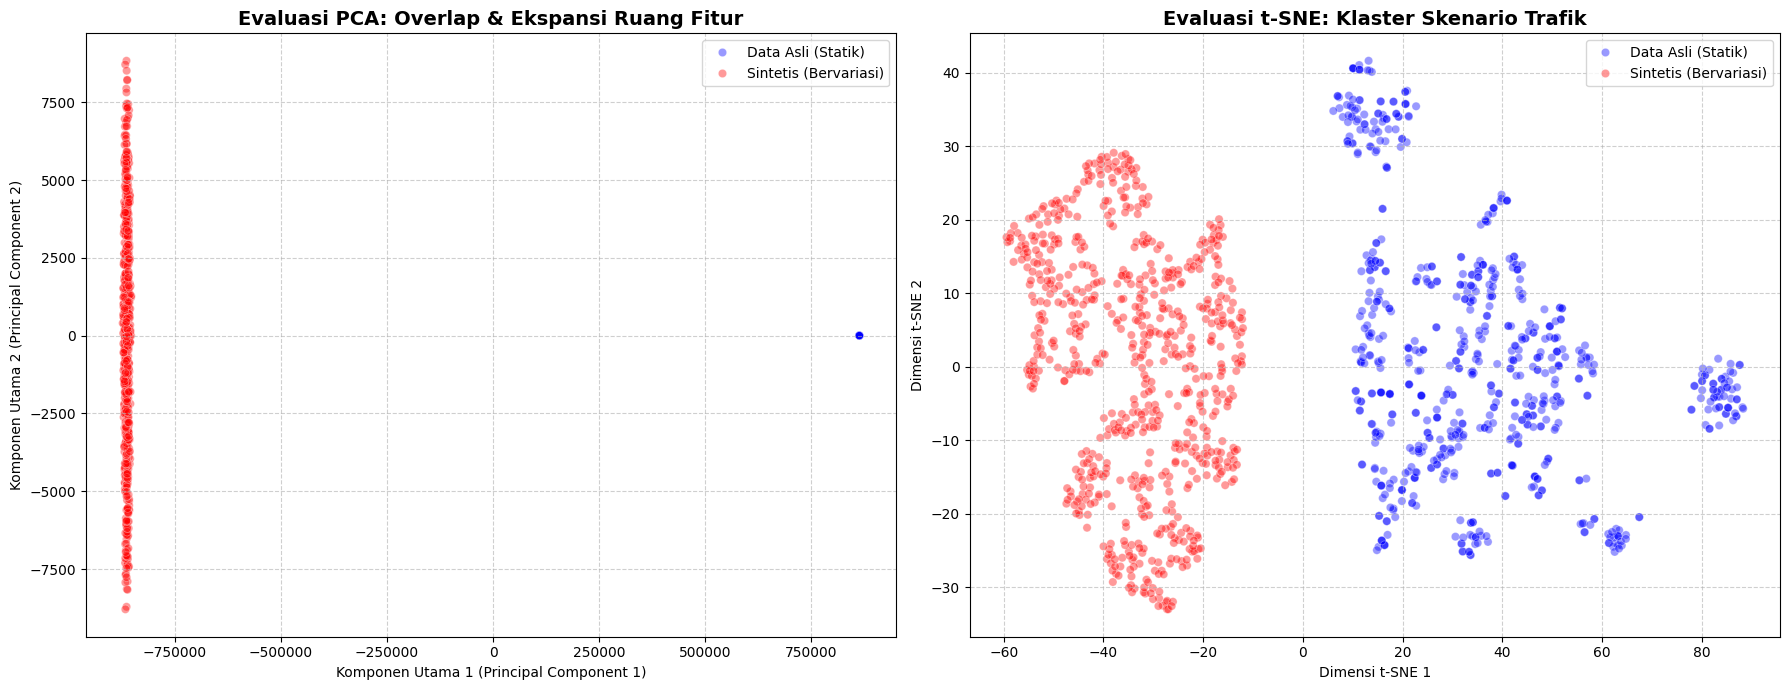

In [6]:
n_viz = 700
real_v = feat_scaled[np.random.choice(len(feat_scaled), n_viz)]
synth_v = scaler.transform(df_synth.iloc[:n_viz])

combined = np.vstack([real_v, synth_v])
labels = ['Data Asli (Statik)'] * n_viz + ['Sintetis (Bervariasi)'] * n_viz

pca_res = PCA(n_components=2).fit_transform(combined)
tsne_res = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(combined)

plt.figure(figsize=(18, 7))

# PCA
plt.subplot(1, 2, 1)
sns.scatterplot(x=pca_res[:,0], y=pca_res[:,1], hue=labels, palette=['#0000FF', '#FF0000'], alpha=0.4)
plt.title("Evaluasi PCA: Overlap & Ekspansi Ruang Fitur", fontsize=14, fontweight='bold')
plt.xlabel("Komponen Utama 1 (Principal Component 1)")
plt.ylabel("Komponen Utama 2 (Principal Component 2)")
plt.grid(True, linestyle='--', alpha=0.6)

# t-SNE
plt.subplot(1, 2, 2)
sns.scatterplot(x=tsne_res[:,0], y=tsne_res[:,1], hue=labels, palette=['#0000FF', '#FF0000'], alpha=0.4)
plt.title("Evaluasi t-SNE: Klaster Skenario Trafik", fontsize=14, fontweight='bold')
plt.xlabel("Dimensi t-SNE 1")
plt.ylabel("Dimensi t-SNE 2")
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Data Augmentation Evaluation
Kode di bawah ini merupakan metrik evaluasi tambahan yang meliputi:
1. **Wasserstein Distance & PCD (Pairwise Correlation Difference)** untuk validasi fidelitas statistik WGAN.
2. **SDN Logic Constraint Check** untuk memverifikasi konsistensi logika jaringan.
3. **KDE & CDF Plots** untuk analisis visual komprehensif distribusi delay.


In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import wasserstein_distance
from sklearn.metrics import mean_squared_error

# Load data
import io

def load_network_data(file_path):
    with open(file_path, 'r') as f:
        lines = f.readlines()
    cleaned = [line.strip().replace('"', '') for line in lines]
    df = pd.read_csv(io.StringIO("\n".join(cleaned)), sep=';', decimal=',')
    return df

df_real = load_network_data('dataset_dqn_rich.csv')
df_fake = pd.read_csv('synthetic_15k_complete_final.csv')

# Pastikan hanya mengambil kolom numerik yang relevan
cols = ['rx_mbps_p1', 'util_rx_pct_p1', 'rx_mbps_p2', 'util_rx_pct_p2', 
        'rx_mbps_p4', 'util_rx_pct_p4', 'delay_ms_p4']


In [8]:
def evaluate_fidelity(df_real, df_fake, columns):
    results = {}
    
    # 1. Wasserstein Distance (Semakin kecil semakin baik)
    wd_scores = {}
    for col in columns:
        wd_scores[col] = wasserstein_distance(df_real[col], df_fake[col])
    
    # 2. Pairwise Correlation Difference (PCD)
    corr_real = df_real[columns].corr().values
    corr_fake = df_fake[columns].corr().values
    pcd_score = np.linalg.norm(corr_real - corr_fake, ord='fro') # Frobenius norm
    
    return wd_scores, pcd_score

wd_results, pcd_val = evaluate_fidelity(df_real, df_fake, cols)

print("--- Statistical Fidelity Results ---")
print(f"PCD Score (Correlation Stability): {pcd_val:.4f}")
for col, score in wd_results.items():
    print(f"Wasserstein Distance [{col}]: {score:.4f}")


--- Statistical Fidelity Results ---
PCD Score (Correlation Stability): 4.3492
Wasserstein Distance [rx_mbps_p1]: 0.8244
Wasserstein Distance [util_rx_pct_p1]: 49.7800
Wasserstein Distance [rx_mbps_p2]: 1.5281
Wasserstein Distance [util_rx_pct_p2]: 35.8972
Wasserstein Distance [rx_mbps_p4]: 1.0819
Wasserstein Distance [util_rx_pct_p4]: 58.3993
Wasserstein Distance [delay_ms_p4]: 0.4474


In [9]:
def check_sdn_logic(df):
    # Logika: Jika traffic > policing rate, maka packet drop tidak boleh 0
    # Kita menggunakan data yang ada, di sini df_fake
    if 'policing_rate_kbps_p4' in df.columns:
        violations = df[ (df['rx_mbps_p4'] > df['policing_rate_kbps_p4']/1000) & (df['delay_ms_p4'] < 1) ]
        logic_score = (len(violations) / len(df)) * 100
    else:
        # Jika policing rate tidak ada di output sintetis final, kita cek utilitas > 90% tapi delay sangat rendah
        violations = df[ (df['util_rx_pct_p4'] > 90) & (df['delay_ms_p4'] < 1) ]
        logic_score = (len(violations) / len(df)) * 100
        
    return logic_score

logic_err = check_sdn_logic(df_fake)
print(f"\nLogical Consistency Error: {logic_err:.2f}% (Target: 0%)")



Logical Consistency Error: 0.00% (Target: 0%)


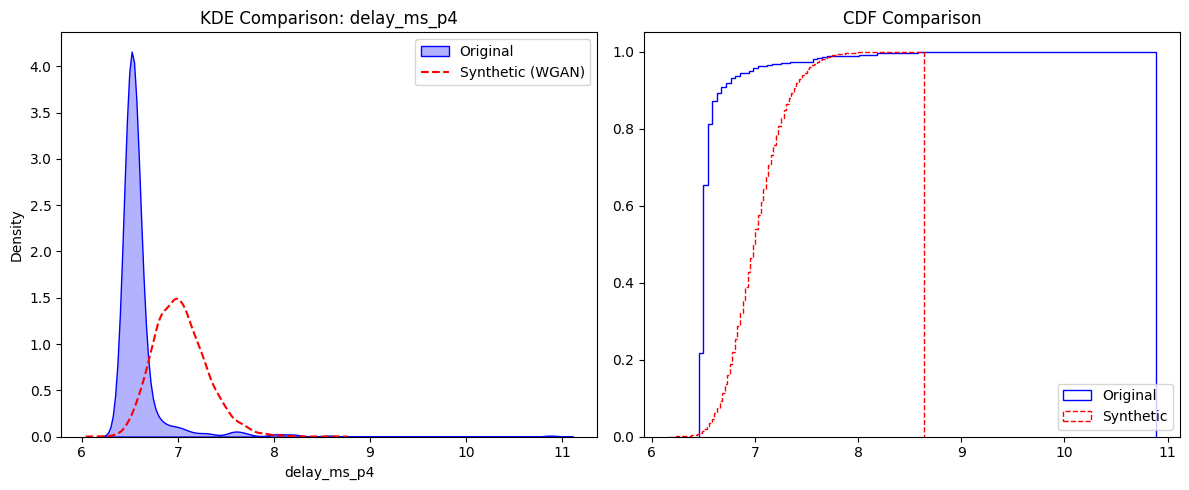

Data evaluasi disimpan di eval_delay_ms_p4.csv


In [10]:
def plot_distributions(df_real, df_fake, feature):
    plt.figure(figsize=(12, 5))
    
    # Plot 1: KDE (Density)
    plt.subplot(1, 2, 1)
    sns.kdeplot(df_real[feature], label='Original', color='blue', fill=True, alpha=0.3)
    sns.kdeplot(df_fake[feature], label='Synthetic (WGAN)', color='red', linestyle='--')
    plt.title(f'KDE Comparison: {feature}')
    plt.legend()
    
    # Plot 2: CDF (Cumulative)
    plt.subplot(1, 2, 2)
    plt.hist(df_real[feature], bins=100, density=True, histtype='step', cumulative=True, label='Original', color='blue')
    plt.hist(df_fake[feature], bins=100, density=True, histtype='step', cumulative=True, label='Synthetic', color='red', linestyle='--')
    plt.title(f'CDF Comparison')
    plt.legend()
    
    plt.tight_layout()
    plt.savefig(f'eval_{feature}.png')
    plt.show()
    
    # Simpan data plot sebagai CSV
    plot_data = pd.DataFrame({
        f'{feature}_Original': df_real[feature].reset_index(drop=True),
        f'{feature}_Synthetic': df_fake[feature].reset_index(drop=True)
    })
    plot_data.to_csv(f'eval_{feature}.csv', index=False)
    print(f"Data evaluasi disimpan di eval_{feature}.csv")

plot_distributions(df_real, df_fake, 'delay_ms_p4')
